<div style="text-align:center; font-size:50px; font-weight:700; margin-top:25px;">
Python pour Data Science - Projet - Groupe 4A
</div>

<div style="text-align:center; font-size:40px; font-weight:700; margin-top:25px;">
Prédiction des prix immobiliers
</div>

<br>

<div style="display:flex; justify-content:space-between; margin-top:35px; font-size:20px;">

  <div style="width:45%;">
    <div style="font-size:22px; font-weight:700; margin-bottom:10px;">Étudiants :</div>
    <div>• Yassine MELLOUL</div>
    <div>• Amira BARHOUMI</div>
    <div>• Antoine FOUCART</div>
  </div>

  <div style="width:45%; text-align:right;">
    <div style="font-size:22px; font-weight:700; margin-bottom:10px;">Chargé de TD :</div>
    <div>Julien PRAMIL</div>
  </div>

</div>

<br>
<hr>

# **1 - DESCRIPTION ET PROBLEMATIQUE**

Dans un contexte où les prix immobiliers sont fortement hétérogènes selon les territoires, le marché du logement en France présente de fortes disparités liées à la localisation, à 

l’attractivité des zones et aux dynamiques socio-économiques locales. Cette variabilité rend complexe la compréhension des mécanismes de formation des prix. Ainsi, la problématique 

centrale de ce projet est d’identifier et quantifier les facteurs influençant le prix de l’immobilier à l’échelle des communes. Nous nous concentrons en particulier sur des déterminants 

socio-économiques tels que la densité de population, le taux de chômage, le revenu moyen et le taux de pauvreté, afin d’évaluer leur impact sur les niveaux de prix. Pour cela, nous 

mobilisons deux sources de données principales : la base DVF (Demandes de Valeurs Foncières), qui recense les transactions immobilières en France , et les données socio-économiques de 

l’INSEE . Les jeux de données utilisés sont accessibles respectivement sur data.gouv.fr et insee.fr, via les liens suivants : 
https://www.data.gouv.fr/datasets/demandes-de-valeurs-foncieres et https://www.insee.fr/fr/statistiques/5359146 .

In [1]:
# IMPORTATION
# modules
import pandas as pd
import numpy as np

# fonctions
from src.data.collect import load__data_url_zip_txt, load_insee_dossier_complet
from src.data.clean import filter_dvf_columns, compute_prix_m2, preprocess_insee, merge_dvf_insee
from src.data.stats_desc import univariate_numeric_analysis, carte_dep_communes_cartiflette, analyse_bivariée_quant_quant
#URL
url_dvf = "https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20260405-002321/valeursfoncieres-2025.txt.zip"
url_insee = "https://www.insee.fr/fr/statistiques/fichier/5359146/dossier_complet.zip"






# **2 - COLLECTE DE DONNEES ET NETTOYAGE**

## **2-1 COLLECTE**

In [2]:
# collecte de la base dvf
dvf = load__data_url_zip_txt(url_dvf)

# aperçu des données brutes
summary_dvf = dvf.dtypes.to_frame(name="type")
summary_dvf["nb_valeurs_manquantes"] = dvf.isna().sum()

summary_dvf = summary_dvf.reset_index().rename(columns={"index": "variable"})

n_rows, n_cols = dvf.shape

print(f"Nombre de lignes : {n_rows}")
print(f"Nombre de colonnes : {n_cols}")

print(summary_dvf)
print(dvf.head(2))

Nombre de lignes : 3714829
Nombre de colonnes : 43
                      variable     type  nb_valeurs_manquantes
0      Identifiant de document  float64                3714829
1           Reference document  float64                3714829
2               1 Articles CGI  float64                3714829
3               2 Articles CGI  float64                3714829
4               3 Articles CGI  float64                3714829
5               4 Articles CGI  float64                3714829
6               5 Articles CGI  float64                3714829
7               No disposition    int64                      0
8                Date mutation   object                      0
9              Nature mutation   object                      0
10             Valeur fonciere   object                  48420
11                     No voie  float64                1313923
12                       B/T/Q   object                3543506
13                Type de voie   object                1391498
14  

In [3]:
# collecte de la base INSEE
insee = load_insee_dossier_complet(url_insee)

# aperçu des données brutes
summary_insee = insee.dtypes.to_frame(name="type")
summary_insee["nb_valeurs_manquantes"] = insee.isna().sum()

summary_insee = summary_insee.reset_index().rename(columns={"index": "variable"})

n_rows, n_cols = insee.shape

print(f"Nombre de lignes : {n_rows}")
print(f"Nombre de colonnes : {n_cols}")

print(summary_insee)
print(insee.head(5))

Nombre de lignes : 34988
Nombre de colonnes : 7
       variable     type  nb_valeurs_manquantes
0        CODGEO   object                      0
1       P22_POP  float64                     89
2   P22_ACT1564  float64                     89
3  P22_CHOM1564  float64                     89
4        SUPERF  float64                     85
5         MED21   object                     79
6        TP6021   object                     79
  CODGEO  P22_POP  P22_ACT1564  P22_CHOM1564  SUPERF  MED21 TP6021
0  01001    859.0   431.000000     28.000000   15.95  25820      s
1  01002    273.0   133.000000      2.000000    9.15  24480      s
2  01004  15554.0  7479.600207   1005.744641   24.60  21660   17,0
3  01005   1917.0   999.457257     63.323397   15.92  24610      s
4  01006    114.0    51.000000      5.000000    5.88  24210      s


## **2-1 NETTOYAGE**

### **Base DVF**
Le nettoyage des données DVF vise à construire un jeu de données cohérent et exploitable pour la modélisation du prix immobilier.

Dans un premier temps, seules les variables pertinentes sont conservées : prix de transaction, localisation (code postal, commune, département, code commune), caractéristiques du bien (type de local, surface bâtie) et type de mutation. Les variables inutiles ou trop détaillées sont supprimées.

Ensuite, plusieurs transformations sont appliquées :
- conversion du prix en format numérique (suppression des espaces, gestion des virgules),
- harmonisation des types (variables qualitatives en `string`),
- standardisation des codes géographiques (zfill pour obtenir des codes à 2 et 5 chiffres).

Un filtrage est réalisé pour ne conserver que les observations pertinentes :
- uniquement les ventes,
- prix et surface strictement positifs,
- biens de type *Maison* ou *Appartement*.

Les valeurs manquantes sont supprimées afin d’assurer la qualité des données.

Enfin, une variable dérivée **prix au m²** est calculée comme le ratio entre la valeur foncière et la surface bâtie.

Ce processus permet d’obtenir un jeu de données propre, homogène et directement utilisable pour l’analyse et la modélisation.



In [4]:
# Nettoyage
dvf = filter_dvf_columns(dvf)
# Ajout de la varible prix du metre carré
dvf = compute_prix_m2(dvf)
# aperçu des données tratées
summary_dvf_f = dvf.dtypes.to_frame(name="type")
summary_dvf_f["nb_valeurs_manquantes"] = dvf.isna().sum()

summary_dvf_f = summary_dvf_f.reset_index().rename(columns={"index": "variable"})

n_rows, n_cols = dvf.shape

print(f"Nombre de lignes : {n_rows}")
print(f"Nombre de colonnes : {n_cols}")

print(summary_dvf_f)
print(dvf.head(5))

Nombre de lignes : 1111244
Nombre de colonnes : 12
                     variable            type  nb_valeurs_manquantes
0             valeur_fonciere         float64                      0
1                 code_postal          object                      0
2                     commune  string[python]                      0
3            code_departement          object                      0
4                code_commune          object                      0
5                  type_local  string[python]                      0
6         surface_reelle_bati         float64                      0
7   nombre_pieces_principales         float64                      0
8               Date mutation          object                      0
9             nature_mutation  string[python]                      0
10             annee_mutation           int32                      0
11                    prix_m2         float64                      0
    valeur_fonciere code_postal    commune code_depa

### **Base INSEE**
La fonction `preprocess_insee` a pour objectif de transformer un DataFrame INSEE brut en un jeu de données propre, standardisé et exploitable pour l’analyse statistique ou la modélisation.

Dans un premier temps, une copie du DataFrame est créée afin d’éviter toute modification directe des données d’origine. Cette étape garantit une approche non destructive du traitement.

Ensuite, les colonnes sont renommées pour améliorer leur lisibilité et leur cohérence. Les noms techniques issus de l’INSEE (comme `CODGEO`, `MED21` ou `TP6021`) sont remplacés par des appellations explicites telles que `code_commune`, `mediane_niveau_vie` ou `taux_pauvrete`. Cette standardisation facilite l’écriture du code et la compréhension des variables.

La fonction procède ensuite à la conversion des types de données. Le code commune et la médiane du niveau de vie sont convertis en type `string`, car ils correspondent à des identifiants ou des valeurs textuelles. Le taux de pauvreté subit un nettoyage plus avancé : les valeurs non exploitables comme `"s"` ou `"nd"` sont remplacées par des valeurs manquantes (`NaN`), les virgules sont converties en points pour respecter le format numérique, puis la variable est transformée en nombre et divisée par 100 afin d’obtenir un taux compris entre 0 et 1.

À partir des variables existantes, de nouveaux indicateurs sont créés. Le taux de chômage est calculé en rapportant le nombre de chômeurs de 15 à 64 ans à la population totale, ce qui fournit une mesure simple de la pression du chômage. La densité de population est également construite en divisant la population par la superficie, permettant d’évaluer le degré de concentration des habitants sur le territoire.

Enfin, toutes les lignes contenant des valeurs manquantes sont supprimées avec `dropna()`, afin d’obtenir un jeu de données entièrement complet et cohérent pour les analyses futures.

In [5]:
# Nettoyage
insee = preprocess_insee(insee)

# aperçu des données traitées
summary_insee_f = insee.dtypes.to_frame(name="type")
summary_insee_f["nb_valeurs_manquantes"] = insee.isna().sum()

summary_insee_f = summary_insee_f.reset_index().rename(columns={"index": "variable"})

n_rows, n_cols = insee.shape

print(f"Nombre de lignes : {n_rows}")
print(f"Nombre de colonnes : {n_cols}")

print(summary_insee_f)
print(insee.head(5))

Nombre de lignes : 34988
Nombre de colonnes : 9
                     variable            type  nb_valeurs_manquantes
0                code_commune  string[python]                      0
1                  population         float64                     89
2  nbr_personnes_active_15_64         float64                     89
3           nbr_chomeur_15_64         float64                     89
4                  superficie         float64                     85
5          mediane_niveau_vie         float64                   3684
6               taux_pauvrete         float64                  30591
7                taux_chomage         float64                     95
8                     densite         float64                     89
  code_commune  population  nbr_personnes_active_15_64  nbr_chomeur_15_64  \
0        01001       859.0                  431.000000          28.000000   
1        01002       273.0                  133.000000           2.000000   
2        01004     15554.0     

### **Fusion des deux jeux de données selon code commune**

In [6]:
# merge
data_final = merge_dvf_insee(dvf, insee)
# aperçu
print(data_final.head(6))


   valeur_fonciere code_postal    commune code_departement code_commune  \
0         468000.0        1550     FARGES               01        01158   
1         180000.0        1200  MONTANGES               01        01257   
2         490000.0        1310    BUELLAS               01        01065   
3         490000.0        1310    BUELLAS               01        01065   
4         183000.0        1170        GEX               01        01173   
5         295000.0        1990    BANEINS               01        01028   

    type_local  surface_reelle_bati  nombre_pieces_principales Date mutation  \
0       Maison                111.0                        5.0    07/01/2025   
1  Appartement                 87.0                        4.0    06/01/2025   
2       Maison                190.0                        6.0    06/01/2025   
3       Maison                190.0                        6.0    06/01/2025   
4  Appartement                 35.0                        2.0    09/01/20

# **3 - ANALYSE DESCRIPTIVE**

## **3-1 - Univarié**

### **Valeur foncière**

Analyse univariée : valeur_fonciere
----------------------------------------
mean : 1,033,616.90
std : 9,937,383.38
min : 0.15
max : 695,000,000.00
median : 202,900.00
q1 : 125,000.00
q3 : 330,000.00


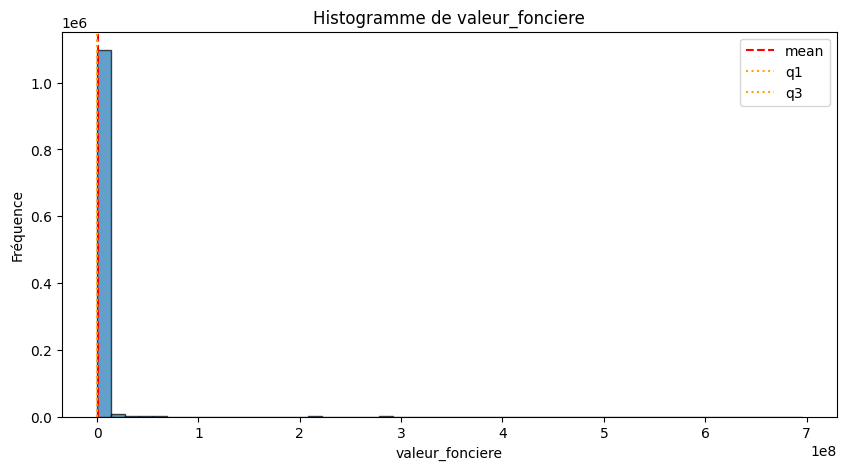

In [7]:
stats = univariate_numeric_analysis(dvf,"valeur_fonciere" )

### **prix du mètre carré**

Analyse univariée : prix_m2
----------------------------------------
mean : 17,925.10
std : 170,986.59
min : 0.00
max : 31,590,909.09
median : 2,734.69
q1 : 1,733.33
q3 : 4,545.45


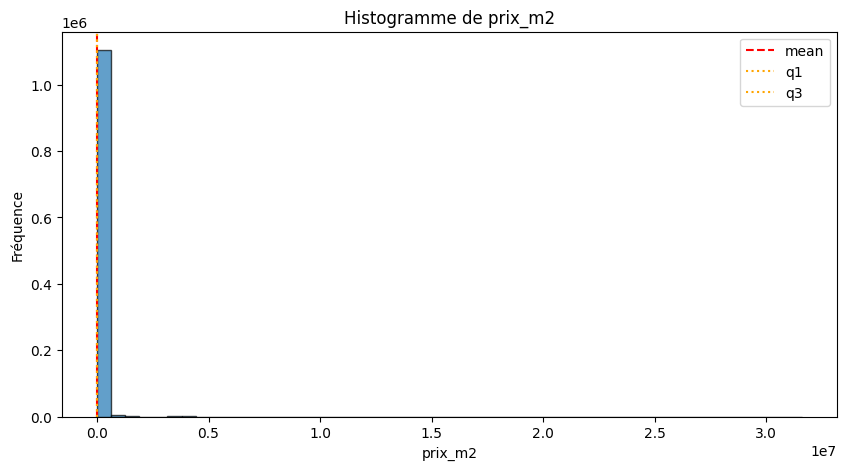

In [8]:
stats2 = univariate_numeric_analysis(dvf,"prix_m2" )

### densité de population

Analyse univariée : densite
----------------------------------------
mean : 2,691.07
std : 5,536.23
min : 0.25
max : 38,142.51
median : 509.63
q1 : 102.02
q3 : 2,749.14


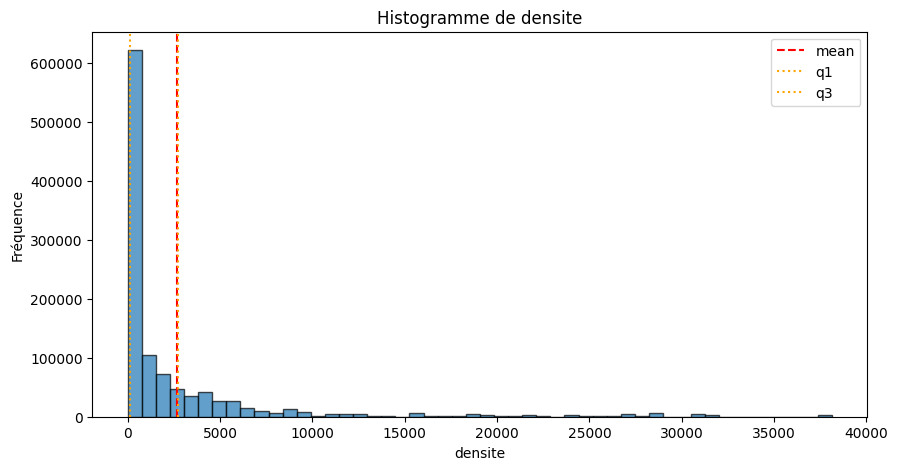

In [9]:
stats3 = univariate_numeric_analysis(data_final,"densite" )

### superficie

Analyse univariée : superficie
----------------------------------------
mean : 29.66
std : 38.04
min : 0.04
max : 758.93
median : 17.95
q1 : 8.87
q3 : 38.04


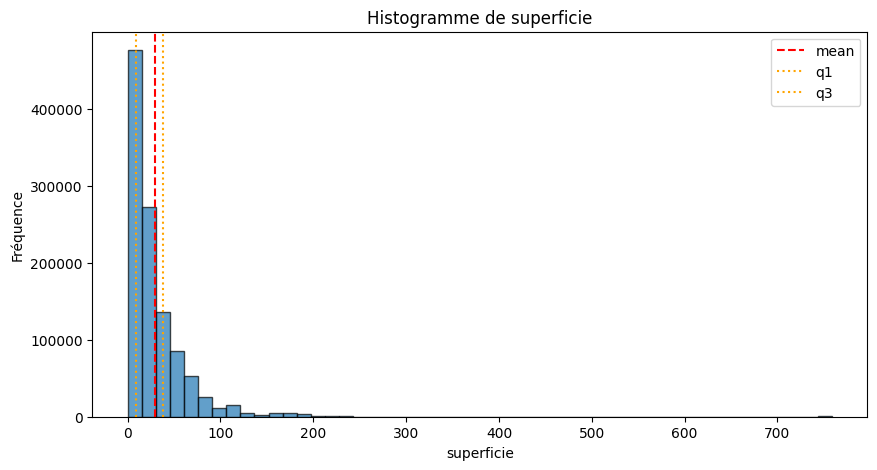

In [10]:
stats4 = univariate_numeric_analysis(data_final,"superficie" )

## **3-2 - Bivarié**

 Corrélations :
           prix_m2   densite
prix_m2  1.000000  0.058418
densite  0.058418  1.000000 

 P-values :
          prix_m2  densite
prix_m2      0.0      0.0
densite      0.0      0.0 



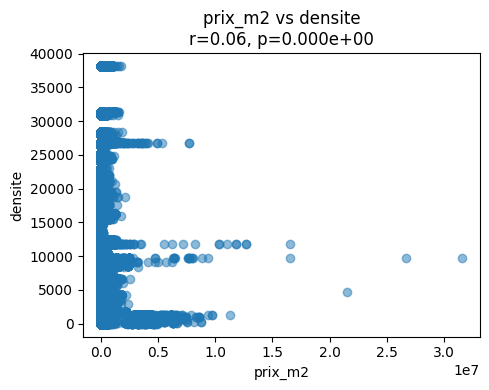

(          prix_m2   densite
 prix_m2  1.000000  0.058418
 densite  0.058418  1.000000,
          prix_m2  densite
 prix_m2      0.0      0.0
 densite      0.0      0.0)

In [11]:
analyse_bivariée_quant_quant(data_final,["prix_m2", "densite"])

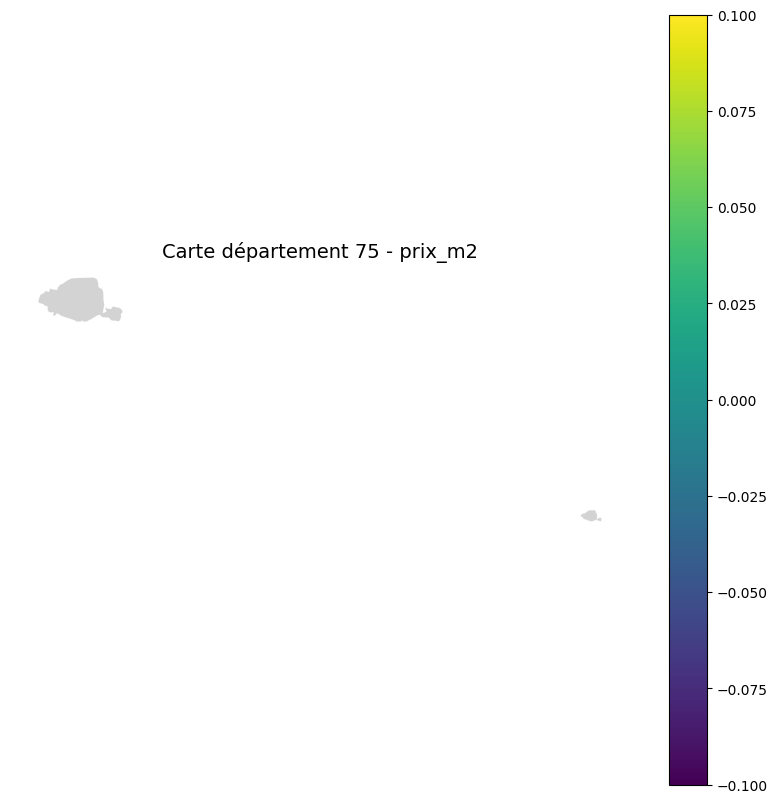

,INSEE_DEP,INSEE_REG,ID,NOM,INSEE_COM,STATUT,POPULATION,AREA,ARR,CV,...,CATEAAV2020,BV2012,LIBELLE_DEPARTEMENT,LIBELLE_REGION,PAYS,SOURCE,geometry,DEP,code_commune,prix_m2
0,75,11,COMMUNE_0000000009736048,Paris,75056,Capitale d'état,2165423,metropole,751,75ZZ,...,11,75056,Paris,Île-de-France,France,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((2.3642 48.8164, 2.38077 48.8217, 2.3...",75,NaN,NaN
1,75,11,COMMUNE_0000000009736048,Paris,75056,Capitale d'état,2165423,metropole,751,75ZZ,...,11,75056,Paris,Île-de-France,France,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((-3.52433 50.31836, -3.45808 50.33892...",75,NaN,NaN


In [14]:
carte_dep_communes_cartiflette(
    df=dvf,
    col="prix_m2",
    code_dep=75
)

# **4 - MODELISATION**